In [ ]:
# 1. List of all fednews_themes (in order)
jobs_themes = [
    "Emotional response",
    "Post-layoff precarities",
    "Career trajectory",
    "Collective resistance",
    "Individual survival strategy",
    "Job Search",
    "Layoff news"
]

# 2. List of all codes (in order of fednews_themes)
jobs_all_codes = [
    # Emotional response
    "Fear/Anxiety",
    "Anger/Blame",
    "Indifference/Humor",
    "Confusion/Surprise",
    "Frustration/Disappointment",
    # Post-layoff precarities
    "Immigration limbo",
    "Family struggle",
    "Financial insecurity",
    "Professional identity collapse",
    # Career trajectory
    "Job-search friction",
    "Anticipation & job insecurity",
    "Unemployment",
    "Career change",
    # Collective resistance
    "Resource-sharing",
    "Legal mobilization",
    "Organizing boycott",
    "Solidarity and appreciation",
    "Whistleblowing",
    # Individual survival strategy
    "Considering quitting",
    "Extra income",
    "Next offer in hand",
    "Seeking legal advice",
    # Job Search
    "Interview advice",
    "Salary negotiation",
    "Seeking referral",  
    # Layoff news
    "News of mass layoff",
    "Individual layoff",
]


## theme code freq image

/tmp/ipykernel_298440/2452141752.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  theme_color_map = plt.cm.get_cmap("tab10", len(themes_sorted))


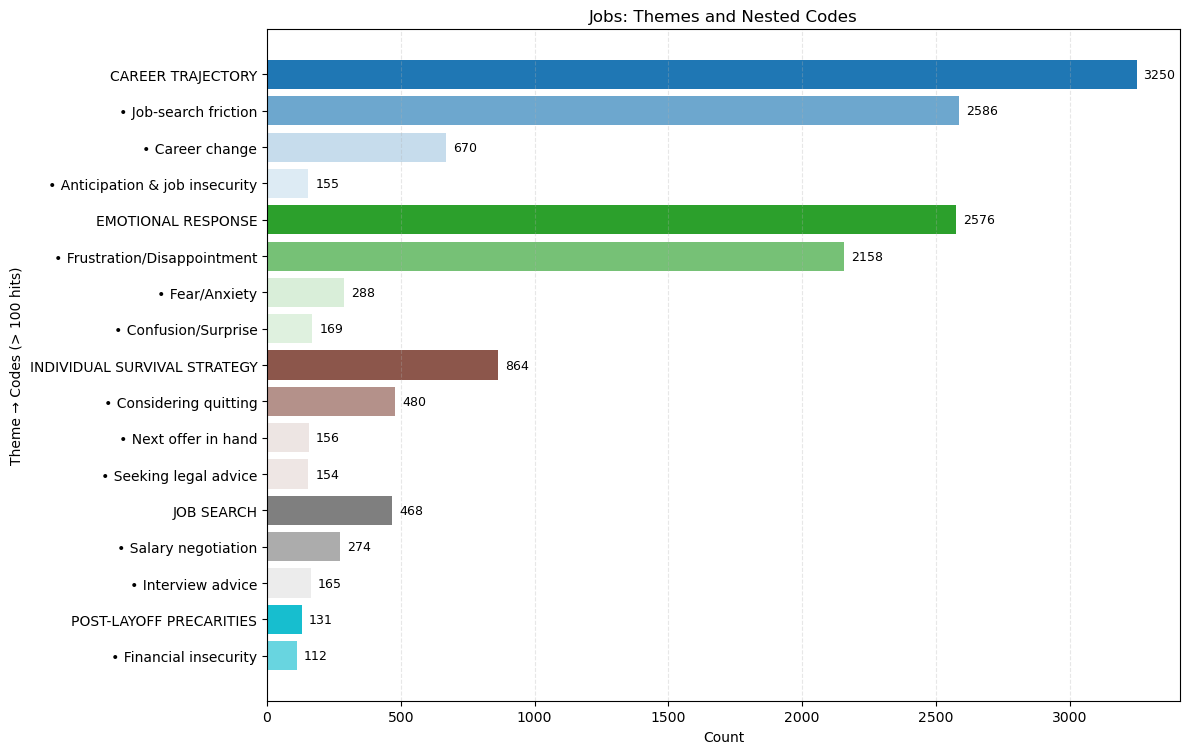

Saved to jobs_theme_codes.png


In [6]:
sorted_jobs_theme_dict = {
    "Career trajectory": {
        "count": 3250,
        "codes": {
            "Job-search friction": 2586,
            "Career change": 670,
            "Anticipation & job insecurity": 155,  # 105 + 50 (case variant)
            "Unemployment": 41,
        },
    },
    "Emotional response": {
        "count": 2576,
        "codes": {
            "Frustration/Disappointment": 2158,
            "Fear/Anxiety": 288,
            "Confusion/Surprise": 169,
            "Anger/Blame": 13,
            "Indifference/Humor": 13,
        },
    },
    "Individual survival strategy": {
        "count": 864,
        "codes": {
            "Considering quitting": 480,
            "Next offer in hand": 156,
            "Seeking legal advice": 154,
            "Extra income": 82,
        },
    },
    "Job Search": {
        "count": 468,
        "codes": {
            "Salary negotiation": 274,
            "Interview advice": 165,
            "Seeking referral": 31,
        },
    },
    "Post-layoff precarities": {
        "count": 131,
        "codes": {
            "Financial insecurity": 112,
            "Family struggle": 11,
            "Immigration limbo": 10,
            "Professional identity collapse": 0,
        },
    },
    "Layoff news": {
        "count": 74,
        "codes": {
            "Individual layoff": 70,
            "News of mass layoff": 3,
        },
    },
    "Collective resistance": {
        "count": 59,
        "codes": {
            "Resource-sharing": 35,
            "Whistleblowing": 11,
            "Solidarity and appreciation": 9,
            "Organizing boycott": 3,
            "Legal mobilization": 1,
        },
    },
}

# --- Params you can tweak ---
TOP_N_THEMES = 5               # how many themes to plot (sorted by count desc)
CODE_MIN_COUNT = 100           # keep codes with count > CODE_MIN_COUNT
OUTPUT_PNG = "jobs_theme_codes.png"

# --- Plot ---
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

def mix_with_white(rgb, t):
    """t in [0,1]; 0 = original rgb, 1 = white; returns lighter color."""
    r, g, b = rgb
    return (r*(1-t) + 1*t, g*(1-t) + 1*t, b*(1-t) + 1*t)

# Select top-N themes by count
themes_sorted = sorted(sorted_jobs_theme_dict.items(), key=lambda kv: kv[1]["count"], reverse=True)[:TOP_N_THEMES]

# Prepare plotting lists
labels, values, colors = [], [], []
theme_color_map = plt.cm.get_cmap("tab10", len(themes_sorted))

for i, (theme, info) in enumerate(themes_sorted):
    base_rgb = to_rgb(theme_color_map(i))
    # Theme bar
    labels.append(theme.upper())
    values.append(info["count"])
    colors.append(base_rgb)

    # Codes: filter & sort by count desc
    codes = {k: v for k, v in info["codes"].items() if v > CODE_MIN_COUNT}
    codes_sorted = sorted(codes.items(), key=lambda kv: kv[1], reverse=True)

    if codes_sorted:
        code_counts = [v for _, v in codes_sorted]
        cmin, cmax = min(code_counts), max(code_counts)
        for code, cnt in codes_sorted:
            # intensity based on count within this theme (always lighter than theme)
            if cmax > cmin:
                norm = (cnt - cmin) / (cmax - cmin)  # 0..1 (low..high)
            else:
                norm = 1.0
            t = 0.35 + 0.50 * (1 - norm)  # high count -> smaller t (more intense); all < theme intensity
            labels.append(f"   • {code}")
            values.append(cnt)
            colors.append(mix_with_white(base_rgb, t))

# Figure height scales with number of bars
fig_h = max(4, 0.45 * len(labels))
plt.figure(figsize=(12, fig_h))

ypos = range(len(labels))
bars = plt.barh(list(ypos), values, color=colors, edgecolor="none")

# Value labels
for y, v in zip(ypos, values):
    plt.text(v + max(values)*0.008, y, f"{v}", va="center", fontsize=9)

plt.gca().invert_yaxis()
plt.xlabel("Count")
plt.ylabel("Theme → Codes (> {} hits)".format(CODE_MIN_COUNT))
plt.title("Jobs: Themes and Nested Codes")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.yticks(list(ypos), labels)
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved to {OUTPUT_PNG}")



/tmp/ipykernel_314469/24052932.py:100: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  fallback_cmap = plt.cm.get_cmap("tab10", max(1, len(themes_sorted)))


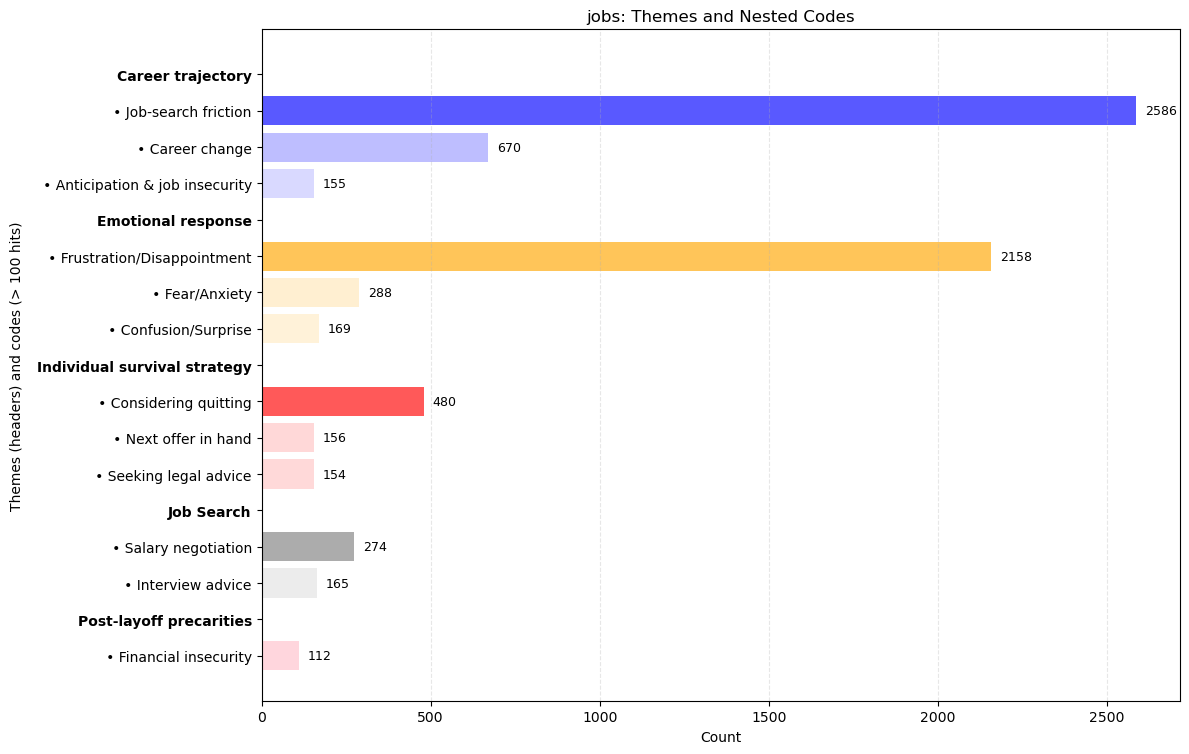

Saved to jobs_theme_codes_v2.png


In [ ]:
sorted_jobs_theme_dict = {
    "Career trajectory": {
        "count": 3250,
        "codes": {
            "Job-search friction": 2586,
            "Career change": 670,
            "Anticipation & job insecurity": 155,  # 105 + 50 (case variant)
            "Unemployment": 41,
        },
    },
    "Emotional response": {
        "count": 2576,
        "codes": {
            "Frustration/Disappointment": 2158,
            "Fear/Anxiety": 288,
            "Confusion/Surprise": 169,
            "Anger/Blame": 13,
            "Indifference/Humor": 13,
        },
    },
    "Individual survival strategy": {
        "count": 864,
        "codes": {
            "Considering quitting": 480,
            "Next offer in hand": 156,
            "Seeking legal advice": 154,
            "Extra income": 82,
        },
    },
    "Job Search": {
        "count": 468,
        "codes": {
            "Salary negotiation": 274,
            "Interview advice": 165,
            "Seeking referral": 31,
        },
    },
    "Post-layoff precarities": {
        "count": 131,
        "codes": {
            "Financial insecurity": 112,
            "Family struggle": 11,
            "Immigration limbo": 10,
            "Professional identity collapse": 0,
        },
    },
    "Layoff news": {
        "count": 74,
        "codes": {
            "Individual layoff": 70,
            "News of mass layoff": 3,
        },
    },
    "Collective resistance": {
        "count": 59,
        "codes": {
            "Resource-sharing": 35,
            "Whistleblowing": 11,
            "Solidarity and appreciation": 9,
            "Organizing boycott": 3,
            "Legal mobilization": 1,
        },
    },
}


# --- Params you can tweak ---
subreddit = "jobs"
TOP_N_THEMES = 5               # how many themes to show (sorted by theme count desc)
CODE_MIN_COUNT = 100           # filter codes with count <= threshold
OUTPUT_PNG = f"{subreddit}_theme_codes_v2.png"

# --- Plot ---
import math
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

# Fixed colors for common themes across platforms
THEME_COLOR_SPEC = {
    "Emotional response": "orange",
    "Post-layoff precarities": "pink",
    "Career trajectory": "blue",
    "Collective resistance": "green",
    "Individual survival strategy": "red",
}

def mix_with_white(rgb, t):
    """t in [0,1]; 0=original rgb, 1=white; returns lighter color."""
    r, g, b = rgb
    return (r*(1-t) + 1*t, g*(1-t) + 1*t, b*(1-t) + 1*t)

# Select top-N themes by count
themes_sorted = sorted(
    sorted_jobs_theme_dict.items(),
    key=lambda kv: kv[1]["count"],
    reverse=True
)[:TOP_N_THEMES]

labels, values, colors, is_header = [], [], [], []
fallback_cmap = plt.cm.get_cmap("tab10", max(1, len(themes_sorted)))

for i, (theme, info) in enumerate(themes_sorted):
    # ----- Theme header (no bar) -----
    labels.append(theme)         # show theme name as a header row
    values.append(0)             # zero-length bar (won't render)
    colors.append("none")        # no face/edge color
    is_header.append(True)

    # ----- Codes for this theme -----
    # base color for this theme (fixed if in THEME_COLOR_SPEC, else fallback palette)
    base_rgb = to_rgb(THEME_COLOR_SPEC.get(theme, fallback_cmap(i)))

    # filter and sort codes
    codes = {k: v for k, v in info["codes"].items() if v > CODE_MIN_COUNT}
    codes_sorted = sorted(codes.items(), key=lambda kv: kv[1], reverse=True)

    if codes_sorted:
        code_counts = [v for _, v in codes_sorted]
        cmin, cmax = min(code_counts), max(code_counts)
        for code, cnt in codes_sorted:
            # normalize within-theme to determine tint (always lighter than the base theme color)
            if cmax > cmin:
                norm = (cnt - cmin) / (cmax - cmin)  # 0..1
            else:
                norm = 1.0
            # high count -> closer to base color; ensure lighter than theme (no theme bar is drawn)
            t = 0.35 + 0.50 * (1 - norm)  # in [0.35, 0.85]
            labels.append(f"   • {code}")
            values.append(cnt)
            colors.append(mix_with_white(base_rgb, t))
            is_header.append(False)

# ---- Render ----
fig_h = max(4, 0.45 * len(labels))
fig, ax = plt.subplots(figsize=(12, fig_h))

ypos = list(range(len(labels)))
bars = ax.barh(ypos, values, color=colors, edgecolor="none")

# Annotate counts for code rows only (skip headers)
if values:
    xmax = max(values)
    for y, v, hdr in zip(ypos, values, is_header):
        if not hdr and v > 0:
            ax.text(v + xmax * 0.01, y, f"{v}", va="center", fontsize=9)

ax.invert_yaxis()
ax.set_xlabel("Count")
ax.set_ylabel(f"Themes and codes (> {CODE_MIN_COUNT} hits)")
ax.set_title(f"{subreddit}: Themes and Nested Codes")

# Y tick labels
ax.set_yticks(ypos)
ax.set_yticklabels(labels)

# Bold theme headers
for y, ticklabel in enumerate(ax.get_yticklabels()):
    if is_header[y]:
        ticklabel.set_fontweight("bold")

ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved to {OUTPUT_PNG}")


/tmp/ipykernel_483801/2505970532.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  fallback_cmap = plt.cm.get_cmap("tab10", max(1, len(themes_sorted)))


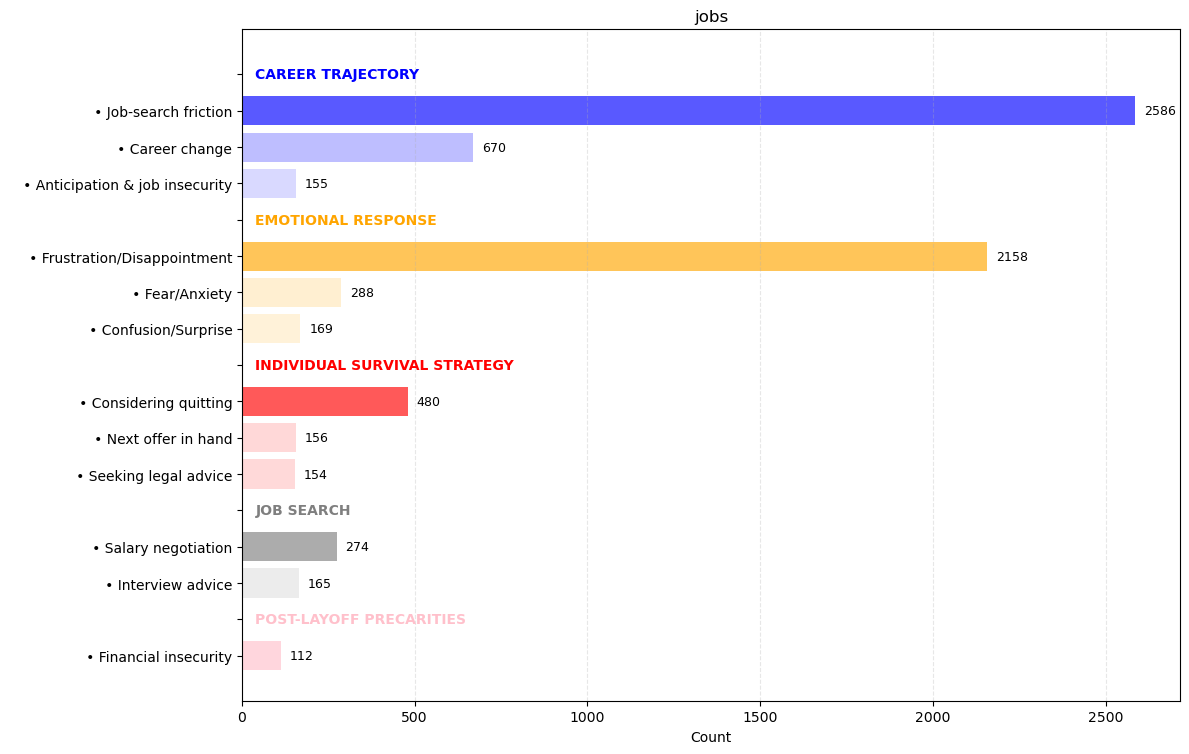

Saved to jobs_theme_codes.png


In [1]:
sorted_jobs_theme_dict = {
    "Career trajectory": {
        "count": 3250,
        "codes": {
            "Job-search friction": 2586,
            "Career change": 670,
            "Anticipation & job insecurity": 155,  # 105 + 50 (case variant)
            "Unemployment": 41,
        },
    },
    "Emotional response": {
        "count": 2576,
        "codes": {
            "Frustration/Disappointment": 2158,
            "Fear/Anxiety": 288,
            "Confusion/Surprise": 169,
            "Anger/Blame": 13,
            "Indifference/Humor": 13,
        },
    },
    "Individual survival strategy": {
        "count": 864,
        "codes": {
            "Considering quitting": 480,
            "Next offer in hand": 156,
            "Seeking legal advice": 154,
            "Extra income": 82,
        },
    },
    "Job Search": {
        "count": 468,
        "codes": {
            "Salary negotiation": 274,
            "Interview advice": 165,
            "Seeking referral": 31,
        },
    },
    "Post-layoff precarities": {
        "count": 131,
        "codes": {
            "Financial insecurity": 112,
            "Family struggle": 11,
            "Immigration limbo": 10,
            "Professional identity collapse": 0,
        },
    },
    "Layoff news": {
        "count": 74,
        "codes": {
            "Individual layoff": 70,
            "News of mass layoff": 3,
        },
    },
    "Collective resistance": {
        "count": 59,
        "codes": {
            "Resource-sharing": 35,
            "Whistleblowing": 11,
            "Solidarity and appreciation": 9,
            "Organizing boycott": 3,
            "Legal mobilization": 1,
        },
    },
}

# --- Params you can tweak ---
subreddit = "jobs"
TOP_N_THEMES = 5                 # how many themes to show (sorted by count desc)
CODE_MIN_COUNT = 100             # filter codes with count <= threshold
OUTPUT_PNG = f"{subreddit}_theme_codes.png"
THEME_LABEL_X_FRAC = 0.015       # theme text x-position as fraction of max count (inside plot)

# --- Plot ---
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

THEME_COLOR_SPEC = {
    "Emotional response": "orange",
    "Post-layoff precarities": "pink",
    "Career trajectory": "blue",
    "Collective resistance": "green",
    "Individual survival strategy": "red",
}

def mix_with_white(rgb, t):
    r, g, b = rgb
    return (r*(1-t) + 1*t, g*(1-t) + 1*t, b*(1-t) + 1*t)

themes_sorted = sorted(
    sorted_jobs_theme_dict.items(),
    key=lambda kv: kv[1]["count"],
    reverse=True
)[:TOP_N_THEMES]

labels, values, colors, is_header = [], [], [], []
groups = []  # store header row index for each theme
fallback_cmap = plt.cm.get_cmap("tab10", max(1, len(themes_sorted)))

for i, (theme, info) in enumerate(themes_sorted):
    base_rgb = to_rgb(THEME_COLOR_SPEC.get(theme, fallback_cmap(i)))

    # header row (no bar) for this theme
    header_idx = len(labels)
    labels.append(theme)
    values.append(0)
    colors.append("none")
    is_header.append(True)

    # codes
    codes = {k: v for k, v in info["codes"].items() if v > CODE_MIN_COUNT}
    codes_sorted = sorted(codes.items(), key=lambda kv: kv[1], reverse=True)

    if codes_sorted:
        code_counts = [v for _, v in codes_sorted]
        cmin, cmax = min(code_counts), max(code_counts)
        for code, cnt in codes_sorted:
            norm = (cnt - cmin) / (cmax - cmin) if cmax > cmin else 1.0
            t = 0.35 + 0.50 * (1 - norm)  # lighter for lower counts
            labels.append(f"   • {code}")
            values.append(cnt)
            colors.append(mix_with_white(base_rgb, t))
            is_header.append(False)

    groups.append({"theme": theme.upper(), "color": base_rgb, "header": header_idx})

# ----- Render -----
fig_h = max(4, 0.45 * len(labels))
fig, ax = plt.subplots(figsize=(12, fig_h))
ypos = list(range(len(labels)))
bars = ax.barh(ypos, values, color=colors, edgecolor="none")

# annotate counts for code rows
if values:
    xmax = max(values) if max(values) > 0 else 1
    for y, v, hdr in zip(ypos, values, is_header):
        if not hdr and v > 0:
            ax.text(v + xmax * 0.01, y, f"{v}", va="center", fontsize=9)

# THEME NAMES: place on the header row (above its group's bars)
x_text = (max(values) if values else 1) * THEME_LABEL_X_FRAC
for g in groups:
    ax.text(x_text, g["header"], g["theme"], va="center", ha="left",
            fontweight="bold", color=g["color"])

# hide header ticks; keep only code labels
yticklabels = [("" if hdr else lbl) for lbl, hdr in zip(labels, is_header)]
ax.set_yticks(ypos)
ax.set_yticklabels(yticklabels)

ax.invert_yaxis()
ax.set_xlabel("Count")
#ax.set_ylabel(f"Codes and Subcodes (> {CODE_MIN_COUNT} hits)")
ax.set_title(f"{subreddit}")
ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved to {OUTPUT_PNG}")


/tmp/ipykernel_483801/3310026773.py:108: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  fallback_cmap = plt.cm.get_cmap("tab10", max(1, len(themes_sorted)))


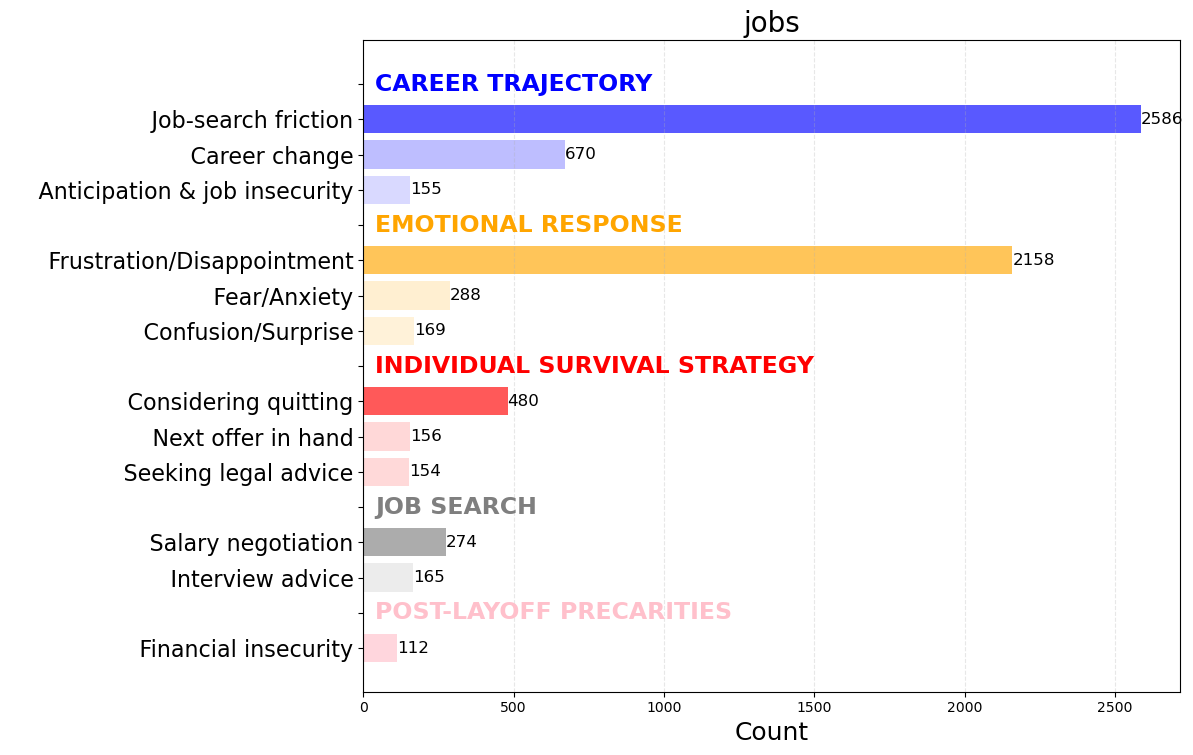

Saved to jobs_theme_codes.png


In [7]:
sorted_jobs_theme_dict = {
    "Career trajectory": {
        "count": 3250,
        "codes": {
            "Job-search friction": 2586,
            "Career change": 670,
            "Anticipation & job insecurity": 155,  # 105 + 50 (case variant)
            "Unemployment": 41,
        },
    },
    "Emotional response": {
        "count": 2576,
        "codes": {
            "Frustration/Disappointment": 2158,
            "Fear/Anxiety": 288,
            "Confusion/Surprise": 169,
            "Anger/Blame": 13,
            "Indifference/Humor": 13,
        },
    },
    "Individual survival strategy": {
        "count": 864,
        "codes": {
            "Considering quitting": 480,
            "Next offer in hand": 156,
            "Seeking legal advice": 154,
            "Extra income": 82,
        },
    },
    "Job Search": {
        "count": 468,
        "codes": {
            "Salary negotiation": 274,
            "Interview advice": 165,
            "Seeking referral": 31,
        },
    },
    "Post-layoff precarities": {
        "count": 131,
        "codes": {
            "Financial insecurity": 112,
            "Family struggle": 11,
            "Immigration limbo": 10,
            "Professional identity collapse": 0,
        },
    },
    "Layoff news": {
        "count": 74,
        "codes": {
            "Individual layoff": 70,
            "News of mass layoff": 3,
        },
    },
    "Collective resistance": {
        "count": 59,
        "codes": {
            "Resource-sharing": 35,
            "Whistleblowing": 11,
            "Solidarity and appreciation": 9,
            "Organizing boycott": 3,
            "Legal mobilization": 1,
        },
    },
}

# --- Params you can tweak (NEW) ---
subreddit = "jobs"
TOP_N_THEMES = 5
CODE_MIN_COUNT = 100
OUTPUT_PNG = f"{subreddit}_theme_codes.png"
THEME_LABEL_X_FRAC = 0.015

# font sizes (NEW)
TITLE_FONTSIZE = 20
AXIS_LABEL_FONTSIZE = 18
YTICK_FONTSIZE = 16          # codes/subcodes size
THEME_FONTSIZE = 17          # theme names inside plot
COUNT_FONTSIZE = 12          # numbers at bar ends

# subcode label formatting (NEW)
INDENT = "    "              # spaces before subcodes
SUBCODE_PREFIX = ""          # set to "• " to bring bullets back

# --- Plot ---
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

THEME_COLOR_SPEC = {
    "Emotional response": "orange",
    "Post-layoff precarities": "pink",
    "Career trajectory": "blue",
    "Collective resistance": "green",
    "Individual survival strategy": "red",
}

def mix_with_white(rgb, t):
    r, g, b = rgb
    return (r*(1-t) + 1*t, g*(1-t) + 1*t, b*(1-t) + 1*t)

themes_sorted = sorted(
    sorted_jobs_theme_dict.items(),
    key=lambda kv: kv[1]["count"],
    reverse=True
)[:TOP_N_THEMES]

labels, values, colors, is_header = [], [], [], []
groups = []
fallback_cmap = plt.cm.get_cmap("tab10", max(1, len(themes_sorted)))

for i, (theme, info) in enumerate(themes_sorted):
    base_rgb = to_rgb(THEME_COLOR_SPEC.get(theme, fallback_cmap(i)))

    # header row (no bar)
    header_idx = len(labels)
    labels.append(theme)             # (unchanged)
    values.append(0)
    colors.append("none")
    is_header.append(True)

    # codes
    codes = {k: v for k, v in info["codes"].items() if v > CODE_MIN_COUNT}
    codes_sorted = sorted(codes.items(), key=lambda kv: kv[1], reverse=True)

    if codes_sorted:
        code_counts = [v for _, v in codes_sorted]
        cmin, cmax = min(code_counts), max(code_counts)
        for code, cnt in codes_sorted:
            norm = (cnt - cmin) / (cmax - cmin) if cmax > cmin else 1.0
            t = 0.35 + 0.50 * (1 - norm)
            # ↓ CHANGED: remove bullet, keep indent; configurable via INDENT/SUBCODE_PREFIX
            labels.append(f"{INDENT}{SUBCODE_PREFIX}{code}")
            values.append(cnt)
            colors.append(mix_with_white(base_rgb, t))
            is_header.append(False)

    groups.append({"theme": theme.upper(), "color": base_rgb, "header": header_idx})

# ----- Render -----
fig_h = max(4, 0.45 * len(labels))
fig, ax = plt.subplots(figsize=(12, fig_h))
ypos = list(range(len(labels)))
bars = ax.barh(ypos, values, color=colors, edgecolor="none")

# annotate counts
if values:
    xmax = max(values) if max(values) > 0 else 1
    for y, v, hdr in zip(ypos, values, is_header):
        if not hdr and v > 0:
            #ax.text(v + xmax * 0.01, y, f"{v}", va="center", fontsize=COUNT_FONTSIZE)  # CHANGED
            ax.annotate(f"{v}", xy=(v, y), xytext=(0, 0), textcoords="offset points",
            va="center", ha="left", fontsize=COUNT_FONTSIZE)


# theme names on header rows (CHANGED: use THEME_FONTSIZE)
x_text = (max(values) if values else 1) * THEME_LABEL_X_FRAC
for g in groups:
    ax.text(x_text, g["header"], g["theme"], va="center", ha="left",
            fontweight="bold", color=g["color"], fontsize=THEME_FONTSIZE)

# y-tick labels (CHANGED: bigger fonts; headers hidden)
yticklabels = [("" if hdr else lbl) for lbl, hdr in zip(labels, is_header)]
ax.set_yticks(ypos)
ax.set_yticklabels(yticklabels, fontsize=YTICK_FONTSIZE)  # CHANGED

ax.invert_yaxis()
ax.set_xlabel("Count", fontsize=AXIS_LABEL_FONTSIZE)      # CHANGED
ax.set_title(f"{subreddit}", fontsize=TITLE_FONTSIZE)     # CHANGED
ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved to {OUTPUT_PNG}")


In [4]:
import json
jsonl_file = "fednews_10k_posts_with_post_id_and_labels.jsonl"  # Replace with your actual file path

code_set = set()

with open(jsonl_file, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            try:
                entry = json.loads(line)
                for code in entry.get("codes", []):
                    code_set.add(code)
            except json.JSONDecodeError:
                print("Error decoding JSON line:", line.strip())
                continue
# Final output
print("Unique Codes Found:")
for code in sorted(code_set):
    print("-", code)
print(f"\nTotal unique codes: {len(code_set)}")


FileNotFoundError: [Errno 2] No such file or directory: 'fednews_10k_posts_with_post_id_and_labels.jsonl'

## checking for missing code

In [14]:
missing_codes = code_set - set(fednews_all_codes)  # Codes in code_set but not in fednews_all_codes
print(f"Missing Codes: {missing_codes}")

Missing Codes: set()


In [11]:
import json

# file path to your jsonl file
#file_path = "your_file.jsonl"

# missing codes you mentioned
missing_codes = {
    "Individual survival strategy"
}

# store results as {code: [post_ids]}
code_to_posts = {code: [] for code in missing_codes}

with open(jsonl_file, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line)
        post_id = data.get("post_id")
        codes = data.get("codes", [])
        
        for code in codes:
            if code in missing_codes:
                code_to_posts[code].append(post_id)

# print results
for code, posts in code_to_posts.items():
    print(f"{code}: {posts}")


Individual survival strategy: []


## visuals

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# === Step 1: Load JSONL file ===
# Replace with your actual file path
jsonl_file = "jobs_10k_posts_with_post_id_and_labels.jsonl"

df = pd.read_json(jsonl_file, lines=True)

# Ensure 'date' is datetime and derive 'month'
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

/tmp/ipykernel_298440/3521211758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=code_freq.values, y=code_freq.index, palette="viridis")


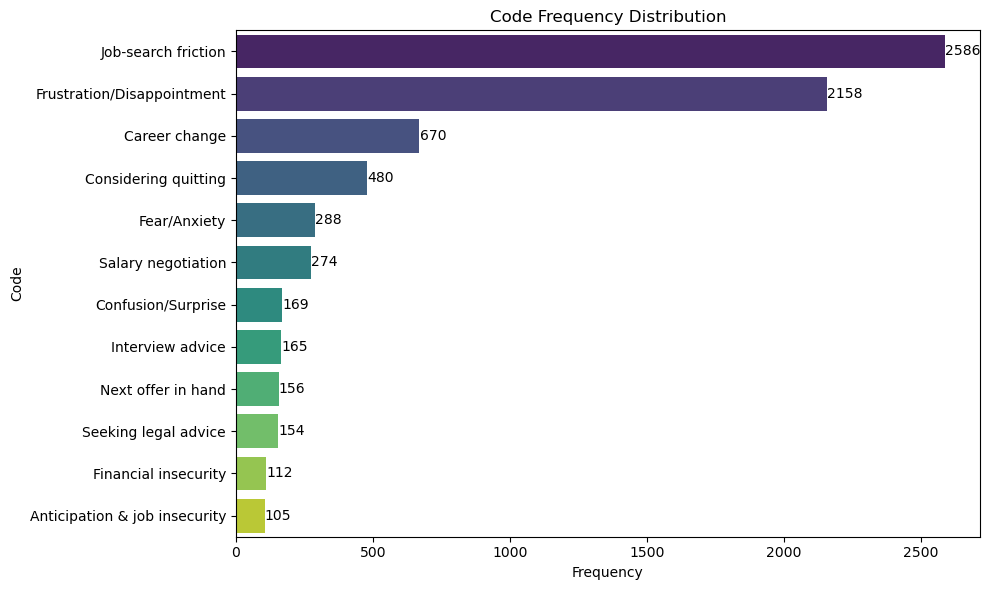

codes
Job-search friction              2586
Frustration/Disappointment       2158
Career change                     670
Considering quitting              480
Fear/Anxiety                      288
Salary negotiation                274
Confusion/Surprise                169
Interview advice                  165
Next offer in hand                156
Seeking legal advice              154
Financial insecurity              112
Anticipation & job insecurity     105
Name: count, dtype: int64


/tmp/ipykernel_298440/3521211758.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=theme_freq.values, y=theme_freq.index, palette="viridis")


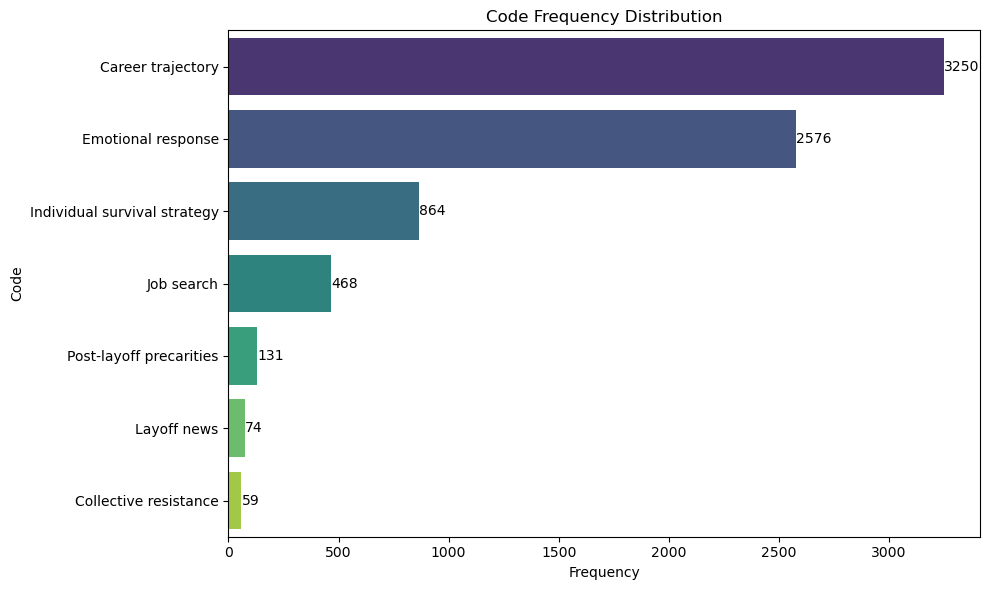

themes
Career trajectory               3250
Emotional response              2576
Individual survival strategy     864
Job search                       468
Post-layoff precarities          131
Layoff news                       74
Collective resistance             59
Name: count, dtype: int64


In [2]:
# Code frequency bar chart
fednews_all_codes = df['codes'].explode()
code_freq = fednews_all_codes.value_counts().sort_values(ascending=False)
# save code frequency to CSV
code_freq.to_csv("code_frequency.csv", header=True)
# only keep codes with more than 100 occurrences
code_freq = code_freq[code_freq > 100]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=code_freq.values, y=code_freq.index, palette="viridis")
plt.title("Code Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Code")
plt.tight_layout()

# Add text labels to each bar
for i, v in enumerate(code_freq.values):
    ax.text(v + 0.5, i, str(v), color='black', va='center')

plt.show()

print(code_freq)



# theme frequency bar chart
all_fednews_themes = df['themes'].explode()
theme_freq = all_fednews_themes.value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=theme_freq.values, y=theme_freq.index, palette="viridis")
plt.title("Code Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Code")
plt.tight_layout()

# Add text labels to each bar
for i, v in enumerate(theme_freq.values):
    ax.text(v + 0.5, i, str(v), color='black', va='center')

plt.show()

print(theme_freq)

# # save code frequency to CSV
# code_freq.to_csv("code_frequency.csv", header=True)
# save theme frequency to CSV
theme_freq.to_csv("theme_frequency.csv", header=True)


/tmp/ipykernel_120749/3767850500.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=theme_freq['count'], y=theme_freq.index, palette="viridis")


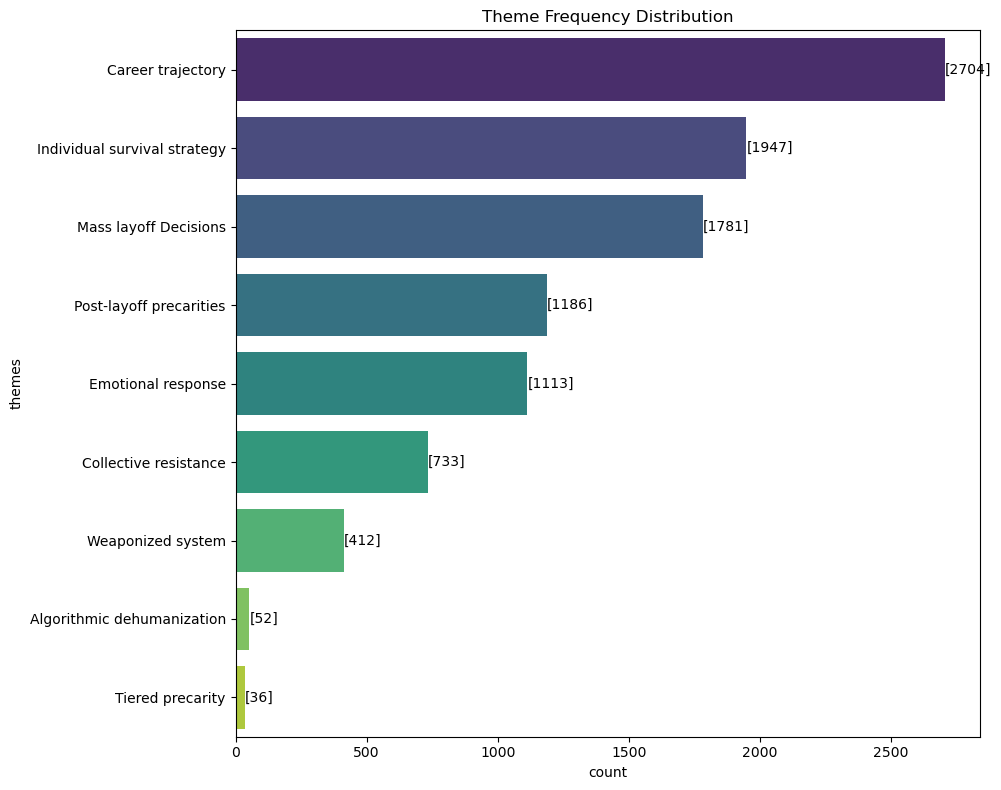

In [8]:
## generate theme frequency bar chart from theme_frequency.csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load theme frequency data
theme_freq = pd.read_csv("theme_frequency.csv", index_col=0)
theme_freq = theme_freq.sort_values(by='count', ascending=False)
plt.figure(figsize=(10, 8))
ax = sns.barplot(x=theme_freq['count'], y=theme_freq.index, palette="viridis")
plt.title("Theme Frequency Distribution")
# plt.xlabel("Frequency")
# plt.ylabel("Theme")
plt.tight_layout()  

for i, v in enumerate(theme_freq.values):
    ax.text(v + 0.8, i, str(v), color='black', va='center')

plt.show()

In [23]:
import numpy as np
# Initialize empty co-occurrence matrix
co_occurrence = pd.DataFrame(0, index=fednews_all_codes, columns=fednews_all_codes)

# Fill matrix from code list per post
for code_list in df['codes']:
    for c1, c2 in combinations(code_list, 2):
        co_occurrence.at[c1, c2] += 1
        co_occurrence.at[c2, c1] += 1
    for c in code_list:
        co_occurrence.at[c, c] += 1  # include diagonal

print("Co-occurrence matrix shape:", co_occurrence.shape)
# save the co-occurrence matrix to CSV
co_occurrence.to_csv("co_occurrence_matrix.csv", header=True)

# Apply log scale for better contrast
log_scaled = np.log1p(co_occurrence)

# Create mask for upper triangle
mask = np.tril(np.ones_like(log_scaled, dtype=bool))

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(log_scaled, mask=mask, cmap="YlGnBu", square=True,
            linewidths=0.5, cbar_kws={"label": "log(1 + count)"})
plt.title("Code Co-occurrence Heatmap (log scale, lower triangle)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [25]:
# === Step 5: Monthly Trends for Selected Codes ===

def plot_monthly_trends(df, sample_codes):
    df_exploded = df.explode('codes')
    monthly_trends = (
        df_exploded[df_exploded['codes'].isin(sample_codes)]
        .groupby(['month', 'codes'])
        .size()
        .unstack(fill_value=0)
    )

    monthly_trends.plot(kind='line', marker='o', figsize=(10, 6))
    plt.title("Monthly Trends of Selected Codes")
    plt.xlabel("Month")
    plt.ylabel("Post Count")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

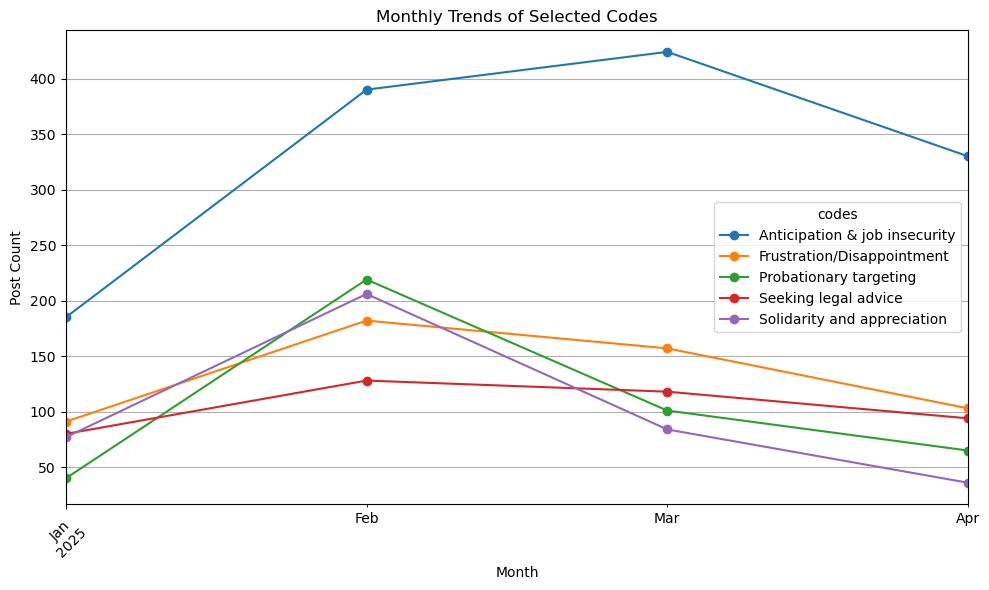

In [28]:
top_5_codes = ["Anticipation & job insecurity", "Frustration/Disappointment", "Probationary targeting", "Seeking legal advice", "Solidarity and appreciation"]
plot_monthly_trends(df, top_5_codes)


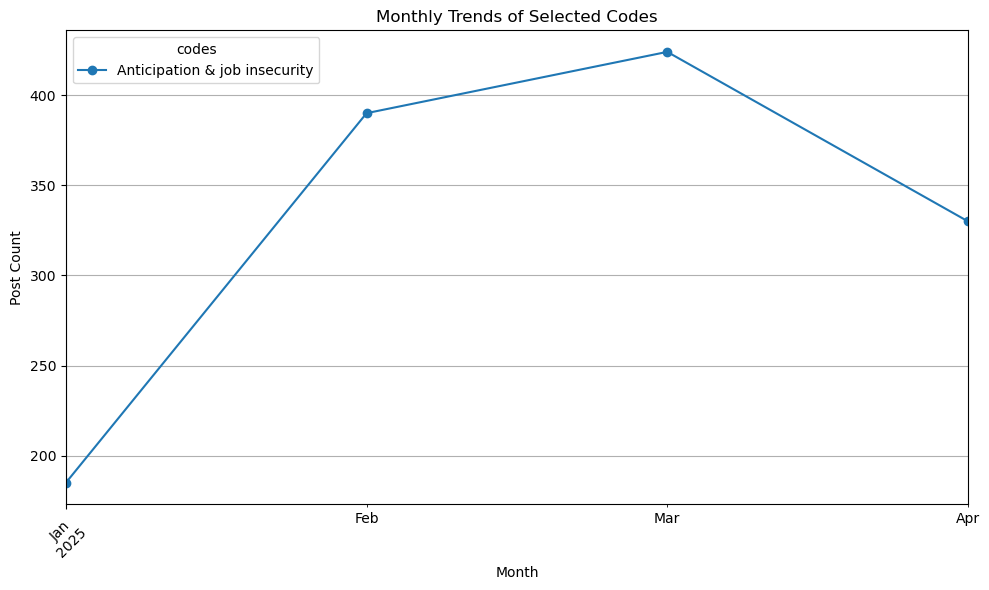

In [27]:
# digging deeper
top_2_codes = ["Anticipation & job insecurity", "News of mass layoff"]
plot_monthly_trends(df, top_2_codes)